<a href="https://colab.research.google.com/github/gtzan/synthesizers_cs_perspective/blob/main/Explaining_the_DFT_a_music_perspective_part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A music and sound exposition of the Discrete Fourier Transform - Part 2
##
## George Tzanetakis - Department of Computer Science, University of Victoria

The Discrete Fourier Transform (DFT) is fundamental for any type of music and sound processing using computers. The goal of this notebook is to develop high-level intuition behind the concepts that underlie the DFT and understand how this transformation is used by various algorithms for audio analysis and synthesis. The intended audience is anyone with some knowledge of high school math that is interested in the topic. This is not a detailed mathematical digital signal processing (DSP) exposition. At the end of the notebook a variety of resources for better understanding the DFT and audio processing are provided for further digging.

There are many great resources for understanding the DFT including textbooks, tutorial articles, and videos some of which are listed at the end of this exposition. This material reflects my own personal way of teaching the DFT that has evolved over twenty years of experience with striving to explain the underlying concepts to students from diverse academic backgrounds and disciplines with a focus on how it connects to music information retrieval.


In Part 1 we looked at how just by combining sinusoid signals of different frequencies and using amplitude envelopes to shape their time evolution we can create complex sounds, melodies and even some chip tune music. Our main focus is going to be the inverse problem. Given a complex sound or a melody or a a chip tune determine all the necessary parameters such as frequencies, amplitudes, duration that would be needed to reconstruct the singal out of sinusoids. We start with the basic problem of amplitude estimation. We will repeat some of the code from part 1 that will be useful.




In [1]:

import numpy as np
import IPython.display as ipd
import librosa
%matplotlib inline
import logging
import matplotlib.pyplot as plt
# Silence the font manager logging system
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# xkcd style plots and suppress font warnings
plt.xkcd()

In [2]:
srate = 22050
def generate_sinusoid(amp = 1.0, freq = 440.0, phase=0.0, dur = 1.0, srate =srate):
  t = np.linspace(0,dur, int(srate* dur))
  data = amp * np.sin(2*np.pi*freq*t+phase)
  return (t,data)

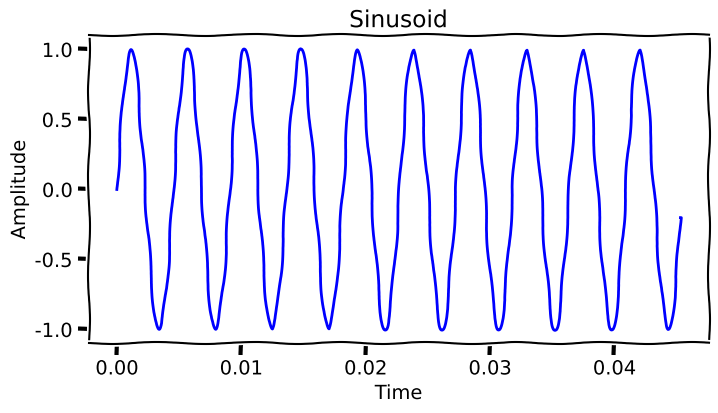

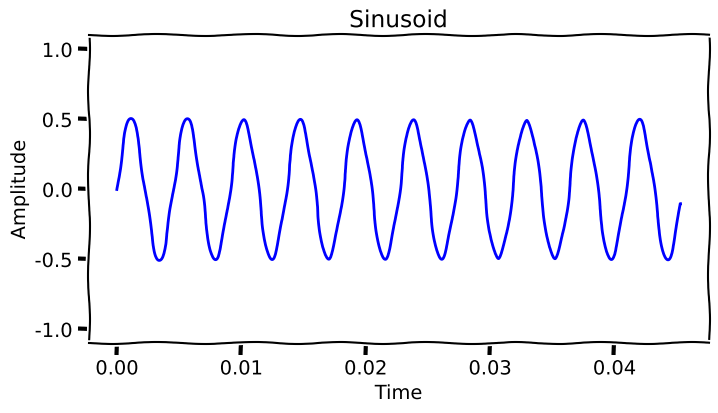

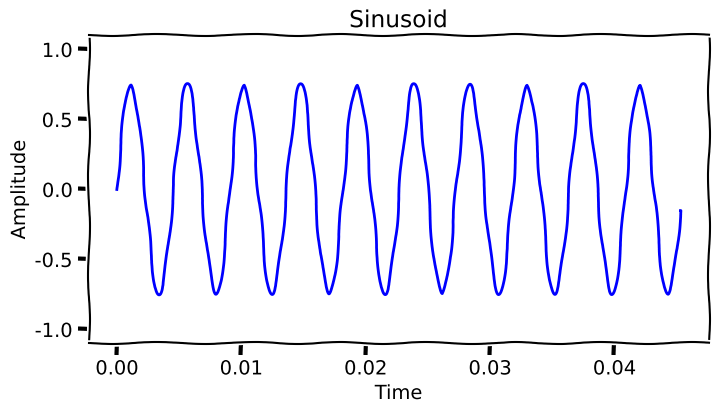

In [5]:
def plot_samples(t, data, start_samples = 0, end_samples = 1000, xlabel="Time", ylabel="Amplitude", title="Sinusoid"):
  fig = plt.figure(figsize=(8,4))
  plt.xlabel(xlabel)
  plt.ylabel(ylabel)
  plt.title(title)
  plt.ylim(-1.1, 1.1) # set the upper and lower limit of the plot

  plt.plot(t[start_samples:end_samples], data[start_samples:end_samples], lw=2, color='blue')
  plt.show()

# create sinusoids with a different amplitudes but the same frequency
(t,audio) = generate_sinusoid(amp=1.0, freq=220)
(t,audio2) = generate_sinusoid(amp=0.5, freq=220.0, dur=2.0, phase=0.0)
(t,audio3) = generate_sinusoid(amp = 0.75, freq=220)
plot_samples(t, audio)
plot_samples(t, audio2)
plot_samples(t,audio3)

# PART 2 Amplitude Estimation

In the previous part we saw that we can construct complex sounds using additive synthesis which combines sinusoids with amplitudes that changes using envelopes. We also showed that we can form melodies and simple polyphonic pieces similar to the chip tunes used in early gaming systems. Our next challenge will be to work on the inverse problem. Given a complex sound or a melody or a piece of music as an array of audio samples we want to find out how we can reconstruct it using appropriate sinusoids with amplitudes, frequencies, and phases that change over time. We will begin this process by considering the estimation of amplitude.


## Peak amplitude estimation
We will start by considering a simplified toy version of the analysis problem. Our first task will be to determine the amplitude of a sinusoid signal given an array of samples. An obvious way to do so is to consider the maximum value of the signal. If we have a few cycles of a sinusoidal signal this should work. We will call this approach **peak amplitude estimation**. Let's check it out.


Peak amplitude = 2.75 
Peak amplitude = 0.50 
Estimated amplitude 2.749999999224653
Estimated amplitude 0.4999999998590279


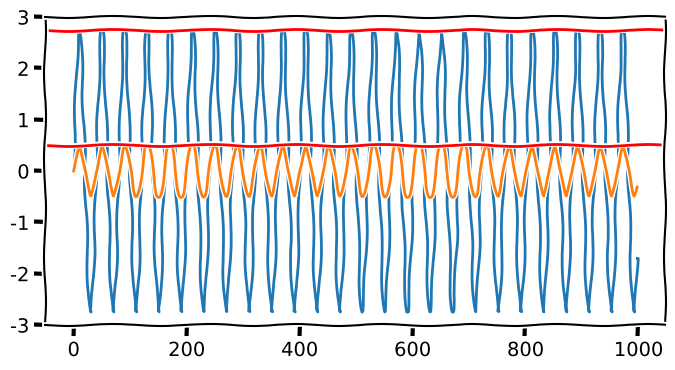

In [6]:
def peak_amplitude(data):
    return np.max(data)

freq = 550
(t,audio1) = generate_sinusoid(amp = 2.75, freq=freq, dur=3)
print('Peak amplitude = %2.2f ' % peak_amplitude(audio1))
(t,audio2) = generate_sinusoid(amp = 0.5, freq=freq, dur=3)
print('Peak amplitude = %2.2f ' % peak_amplitude(audio2))

# We can see how this works visually
plt.figure(figsize=(8,4))
plt.ylim((-3, 3))

plt.plot(audio1[0:999])
plt.plot(audio2[0:999])
plt.axhline(y=peak_amplitude(audio1), color='r', linestyle='-')
plt.axhline(y=peak_amplitude(audio2), color='r', linestyle='-')
print("Estimated amplitude", peak_amplitude(audio1))
print("Estimated amplitude", peak_amplitude(audio2))

We now have a way of measuring the amplitude of sinusoidal signal from an array of digital samples. In more realistic situations when analyzing music and sounds there will not be a single sinusoidal signal but rather combinations of them as well as interferring noise and sounds.Let's look at what happens when we use the peak amplitude estimation method when some noise is added to our input. **An important observation is that as humans we can still hear clearly the sinusoid signal despite the presence of the interferring noise.** The peak amplitude estimation in this more challenging situation is basically useless.


Actual amplitude = 2.75 
Peak amplitude = 4.07 


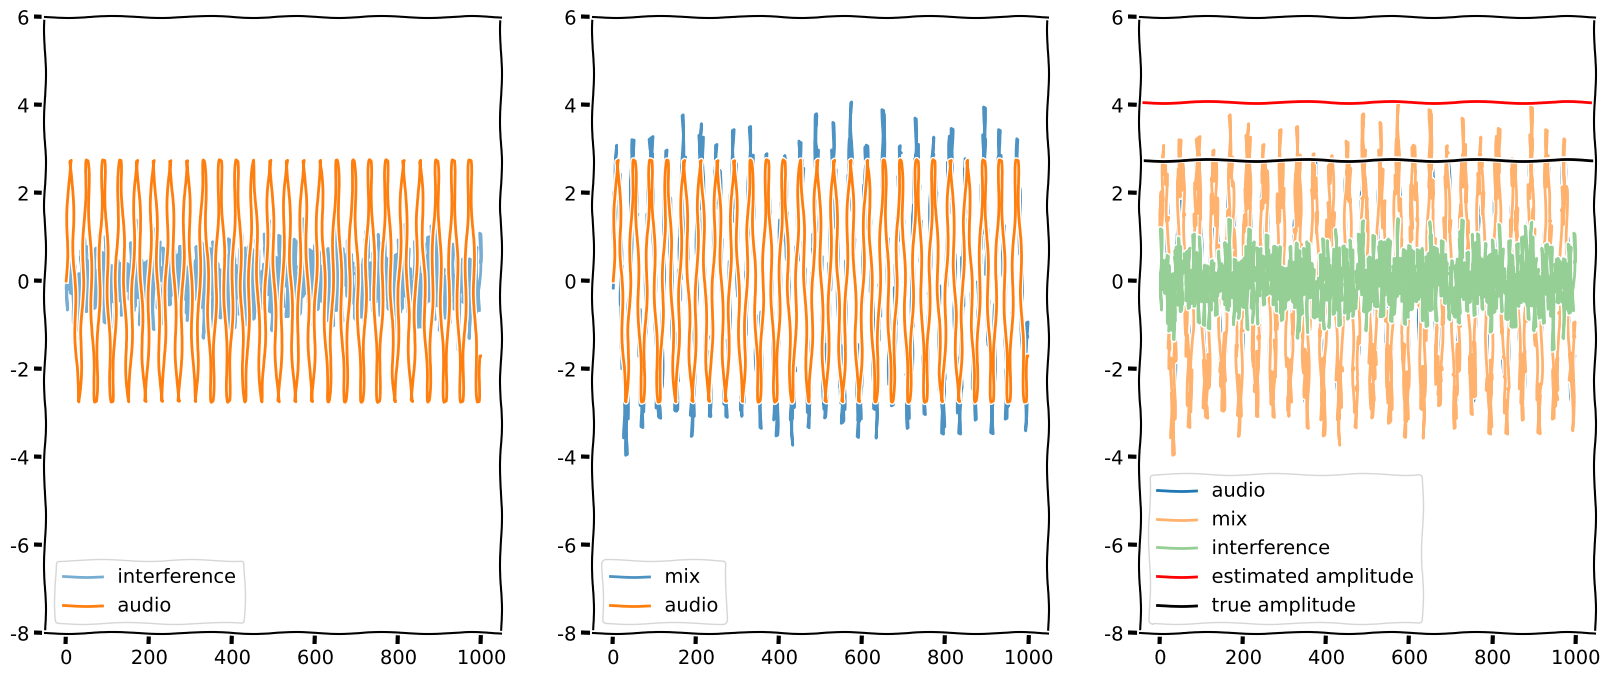

In [13]:
noise = np.random.normal(0, 0.5, len(audio1))
mix = audio1 + noise

def mix_plot(audio, interference, mix, amplitude_function):
  plt.rcParams["figure.figsize"] = (20,8)
  fig, (ax1, ax2, ax3) = plt.subplots(1,3)
  ax1.set_ylim((-8, 6))
  ax1.plot(interference, label = 'interference', alpha=0.6)
  ax1.plot(audio, label='audio')
  ax1.legend(loc='lower left')

  ax2.set_ylim((-8,6))
  ax2.plot(mix, label = 'mix', alpha=0.8)
  ax2.plot(audio, label='audio')

  ax2.legend(loc='lower left')

  ax3.set_ylim((-8,6))
  ax3.plot(audio, label='audio')
  ax3.plot(mix, label = 'mix', alpha=0.6)
  ax3.plot(interference, alpha = 0.5, label='interference')
  ax3.axhline(y=amplitude_function(mix), color='r', linestyle='-', label='estimated amplitude')
  ax3.axhline(y=amplitude_function(audio), color='black', linestyle='-', label='true amplitude')
  ax3.legend(loc='lower left')

mix_plot(audio1[0:999], noise[0:999], mix[0:999], peak_amplitude)
print('Actual amplitude = %2.2f ' % peak_amplitude(audio1[0:999]))
print('Peak amplitude = %2.2f ' % peak_amplitude(mix[0:999]))

ipd.Audio(mix, rate=srate)

# RMS amplitude estimation

So the peak amplitude estimation seems quite sensitive to the interferring noise. Intuititively this makes sense as there we consider only one sample of the array to perform the estimation. A more robust way would be to consider each sample of the arrray for the amplitude estimation. A common approach used in DSP is to perform RMS (Root Mean Squarred) amplitude estimation. The equation for RMS is:

$$
RMS = \sqrt{\vphantom{A^1} \frac{1}{N}\sum_{n=0}^{N-1} x[n]^2}
$$


For the mathematically inclined you can show why in the code below there is a square root of 2 factor in the RMS amplitude estimation of a sinusoid. To do so substitute $x[n]$ with $A \sin(\omega t)$ and then take the integral corresponding to the sum in the continuous case. For the programming inclined create a plot of the original signal and then the squarred signal and visually consider what is the average power of the squarred signal. The signal is first squarred which basically consists of point-wise multiplication with itself. Then the average of that squarred signal is taken followed by a square root operation. The plot bellow shows this visually.

RMS amplitude = 2.75 
RMS amplitude = 3.59 


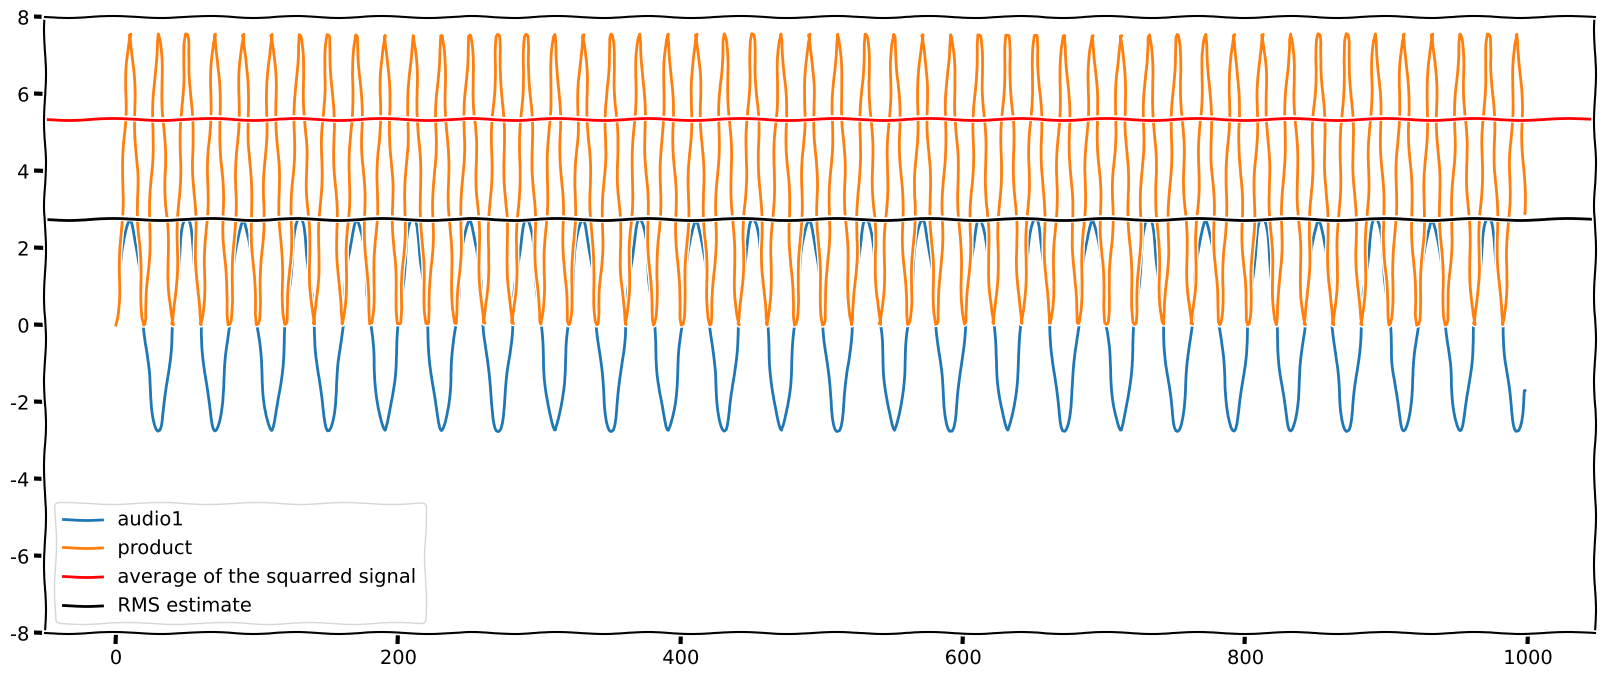

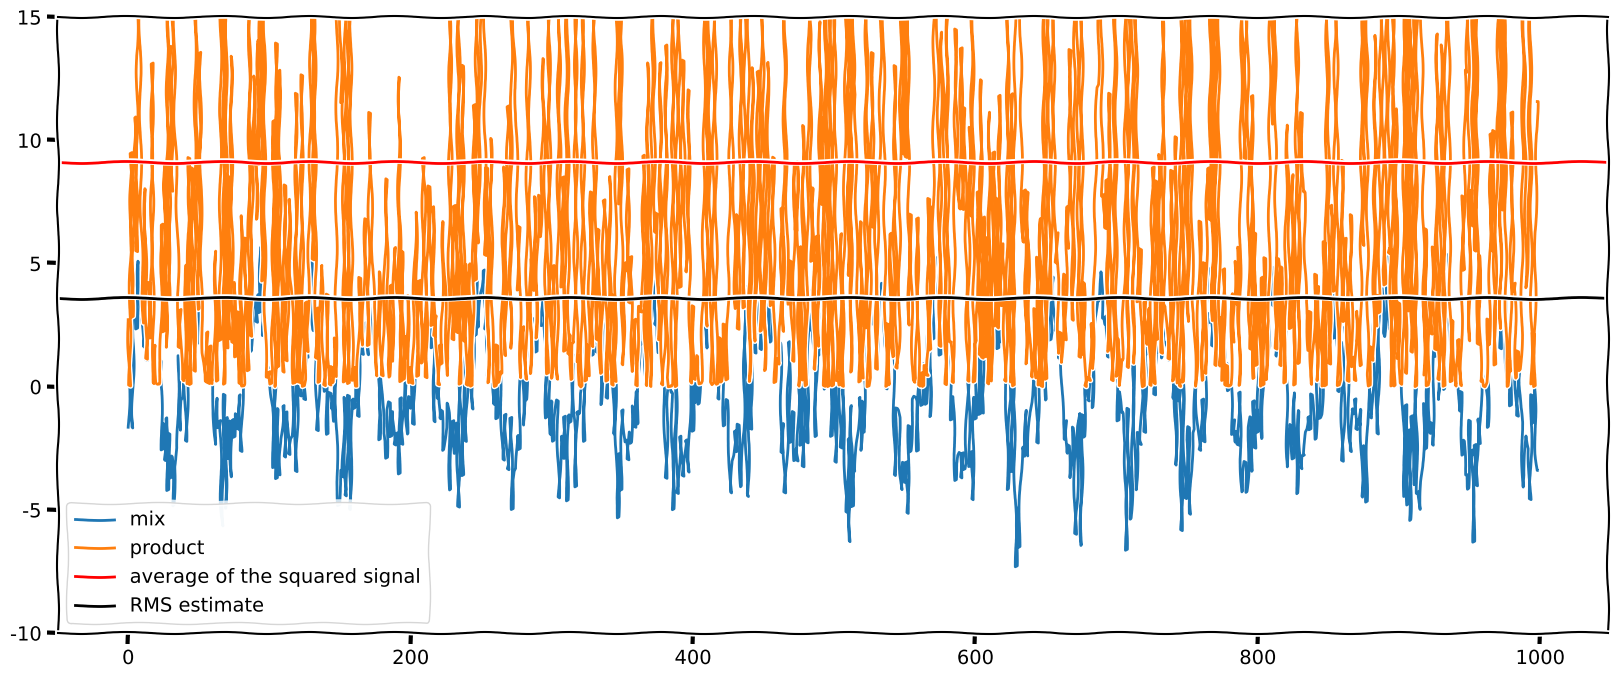

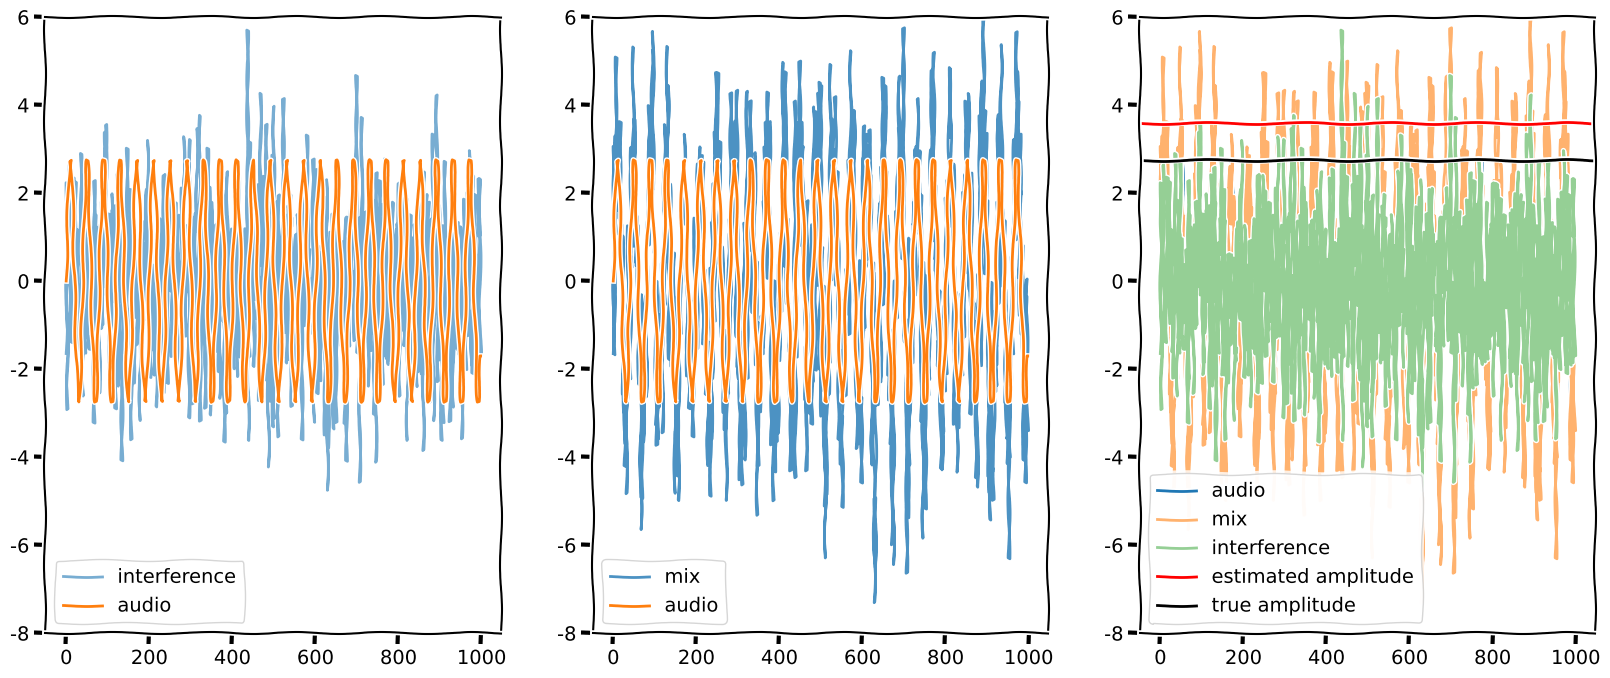

In [16]:
def rms_amplitude(data):
    rms_sum = np.sum(np.multiply(data,data))
    rms_sum /= len(data)
    return np.sqrt(rms_sum) * np.sqrt(2.0)

print('RMS amplitude = %2.2f ' % rms_amplitude(audio1[0:999]))
print('RMS amplitude = %2.2f ' % rms_amplitude(mix[0:999]))

audio_product = np.multiply(audio1[0:999],audio1[0:999])
plt.figure()
plt.ylim((-8, 8))
plt.plot(audio1[0:999], label = 'audio1')
plt.plot(audio_product, label='product')
plt.axhline(y=np.mean(audio_product) * np.sqrt(2.0), color='r', linestyle='-', label='average of the squarred signal')
plt.axhline(y=np.sqrt(np.mean(audio_product)) * np.sqrt(2.0), color='black', linestyle='-', label='RMS estimate')
plt.legend(loc='lower left')

audio_product = np.multiply(mix[0:999],mix[0:999])
plt.figure()
plt.ylim((-10, 15))
plt.plot(mix[0:999], label = 'mix')
plt.plot(audio_product, label='product')
plt.axhline(y=np.mean(audio_product) * np.sqrt(2.0), color='r', linestyle='-', label='average of the squared signal')
plt.axhline(y=np.sqrt(np.mean(audio_product)) * np.sqrt(2.0), color='black', linestyle='-', label='RMS estimate')
plt.legend(loc='lower left')

mix_plot(audio1[0:999], noise[0:999], mix[0:999], rms_amplitude)


So RMS amplitude estimation is more robust to interference than peak amplitude estimation but starts not working well when the amplitude of the interferring noise is larger as one can observe below. Note we are still able to hear the sine wave in noise quite well.

RMS amplitude = 2.75 
RMS amplitude = 3.49 


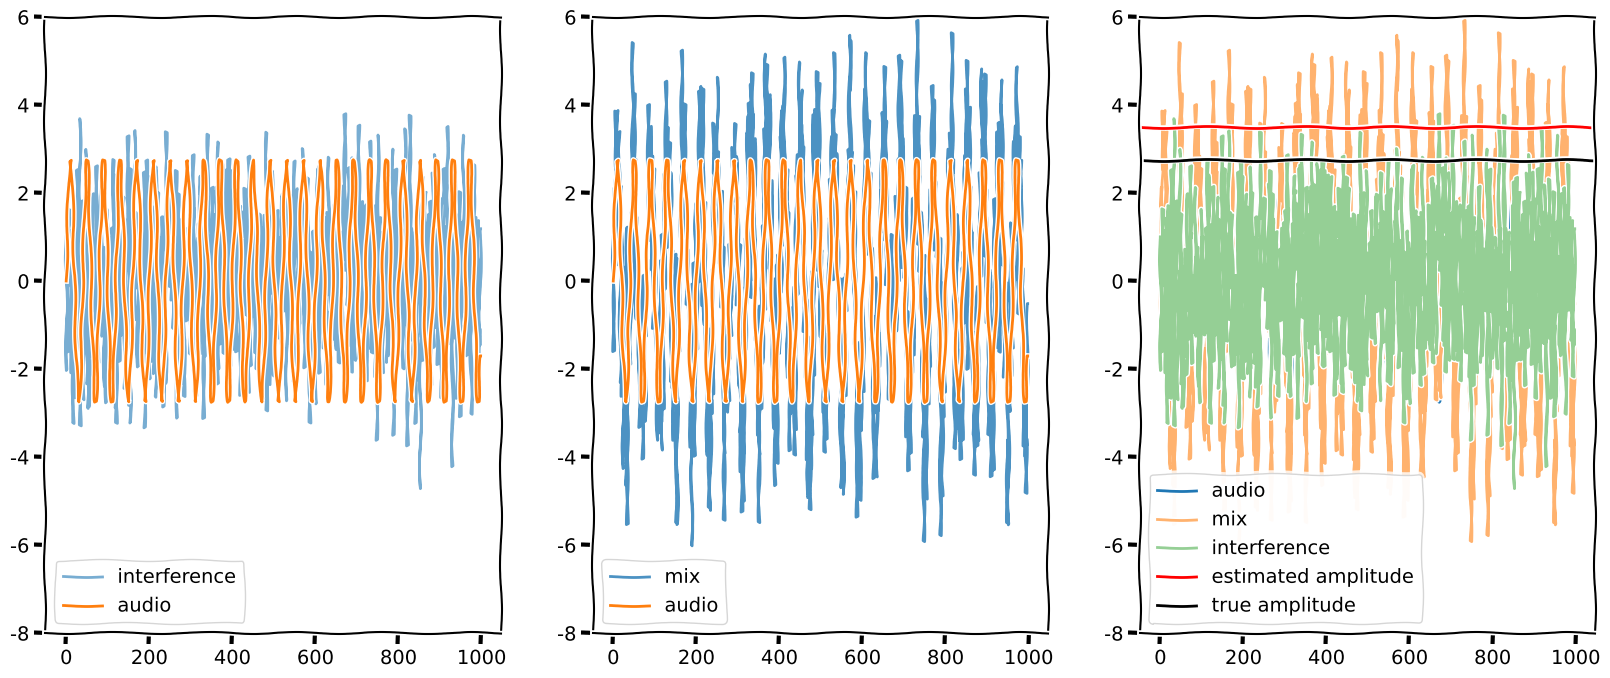

In [17]:
noise = np.random.normal(0, 1.5, len(audio1))
mix = audio1 + noise

print('RMS amplitude = %2.2f ' % rms_amplitude(audio1[0:999]))
print('RMS amplitude = %2.2f ' % rms_amplitude(mix[0:999]))

mix_plot(audio1[0:999], noise[0:999], mix[0:999], rms_amplitude)


ipd.Audio(mix, rate=srate)

## Correlation-based amplitude estimation (dot-product)

To deal more robustly with interference we will have to make some additional assumption to perform amplitude estimation of sinusoidal signal. The additional assumption will be that we know the frequency and phase of the sinusoidal signal that we are trying to estimate the amplitude. Even though this scenario is more restrictive the knowledge of the frequency and phase of what we are looking forward will help us develop a very robust amplitude estimation method.

By knowing the frequency we can reliably estimate the amplitude in much more challenging conditions. To do so we will be utilizing the dot product between two signals/arrays which is defined as:

$$
<x,y> = \sum_{n=0}^{N-1} x[n] * y[n]
$$

Knowing the frequency $\omega$ we are trying to estimate the amplitude for we can create a "probe" sinusoid of the same frequency $\omega$ and unit amplitude. Taking the dot product of our input signal which has other interferring sounds with the "probe" sinusoid will allow us to robustly estimate the amplitude of that sinusoid. **Important note:** this works only if both the sinusoids that is burried with other sounds and the "probe" sinusoids have the same phase. Later on we will use the term "basis" for this "probe" sinusoid of unit amplitude and matching phase.

Correlation is way to describe the similarity between two signal shapes. If the two signals considered are standarized (i.e their mean is set ot 0 and their standard devition to 1) their correlation is equal to their dot-produce.


Dot amplitude = 2.75 
Dot amplitude = 2.74 


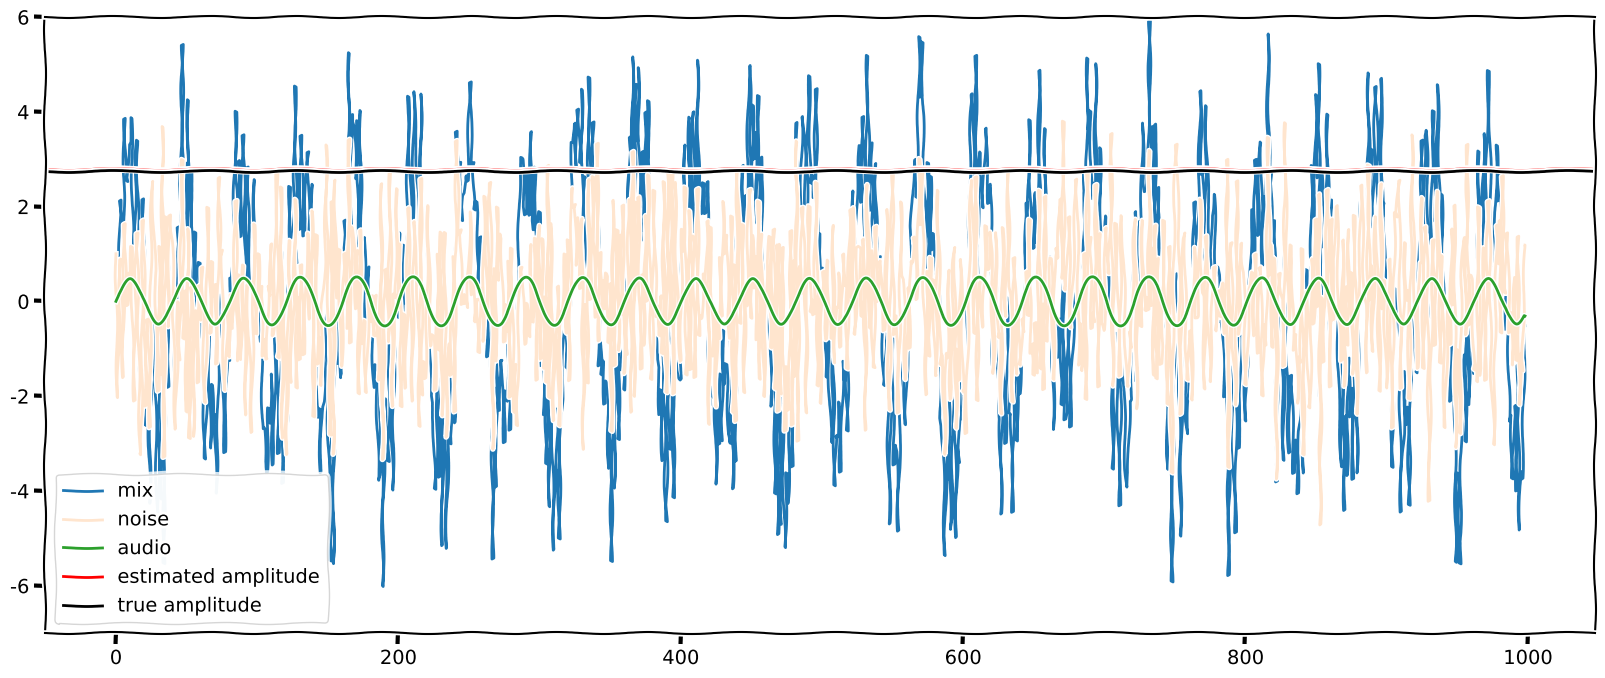

In [19]:
def dot_amplitude_freq(audio, freq):
    dur = audio.shape[0] / srate
    # create the probe/basis sinusoid for the right frequency
    (t,basis) = generate_sinusoid(freq=freq, dur=dur, amp = 1)
    dot_product = np.dot(audio, basis)
    return 2 * (dot_product / len(audio))

freq = 550
print('Dot amplitude = %2.2f ' % dot_amplitude_freq(audio1, freq))
print('Dot amplitude = %2.2f ' % dot_amplitude_freq(mix, freq))


plt.figure()
plt.ylim((-7, 6))
plt.plot(mix[0:999], label = 'mix')
plt.plot(noise[0:999], alpha = 0.2, label='noise')
plt.plot(audio2[0:999], label='audio')

plt.axhline(y=dot_amplitude_freq(mix[0:999], freq), color='r', linestyle='-', label='estimated amplitude')
plt.axhline(y=dot_amplitude_freq(audio1[0:999], freq), color='black', linestyle='-', label='true amplitude')
plt.legend(loc='lower left')


Let's try to see visually how this dot-product amplitude estimation given a frequency of interest works. The orange plot is the multiplication of the input signal with the probe signal. The average of the point-wise multiplication result is the red line. In this case it corresponds to half the amplitude so we scale by 2 to get the dot-product amplitude estimation.

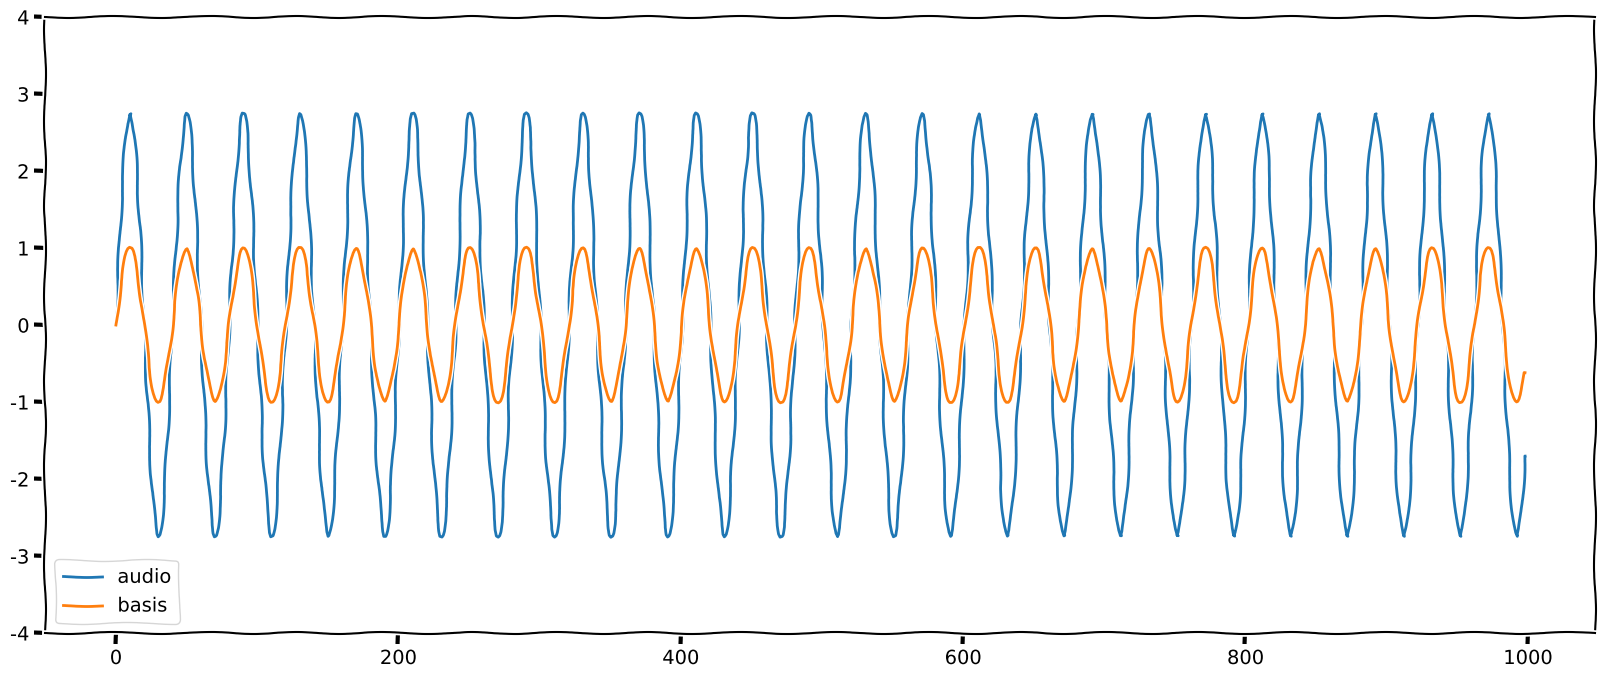

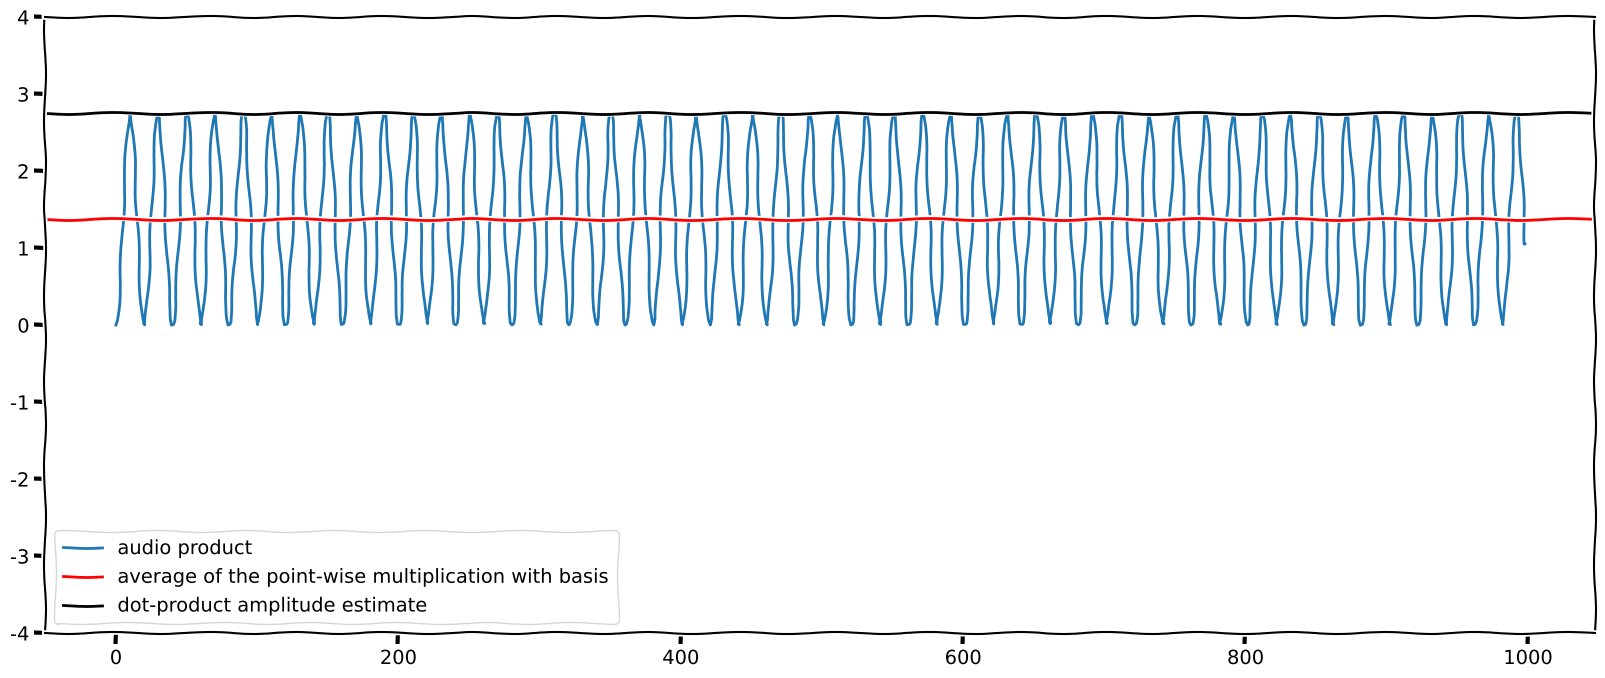

In [20]:
dur = audio1.shape[0] / srate
(t,basis) = generate_sinusoid(freq=freq, dur=dur, amp = 1)

audio_product = np.multiply(audio1[0:999],basis[0:999])
basis = basis[0:999]
plt.figure()
plt.ylim((-4, 4))
plt.plot(audio1[0:999], label = 'audio')
plt.plot(basis, label='basis')
plt.legend(loc='lower left')


plt.figure()
plt.ylim((-4, 4))
plt.plot(audio_product, label='audio product')
plt.axhline(y=np.mean(audio_product), color='r', linestyle='-', label='average of the point-wise multiplication with basis')
plt.axhline(y=2 * np.mean(audio_product), color='black', linestyle='-', label='dot-product amplitude estimate')
plt.legend(loc='lower left')

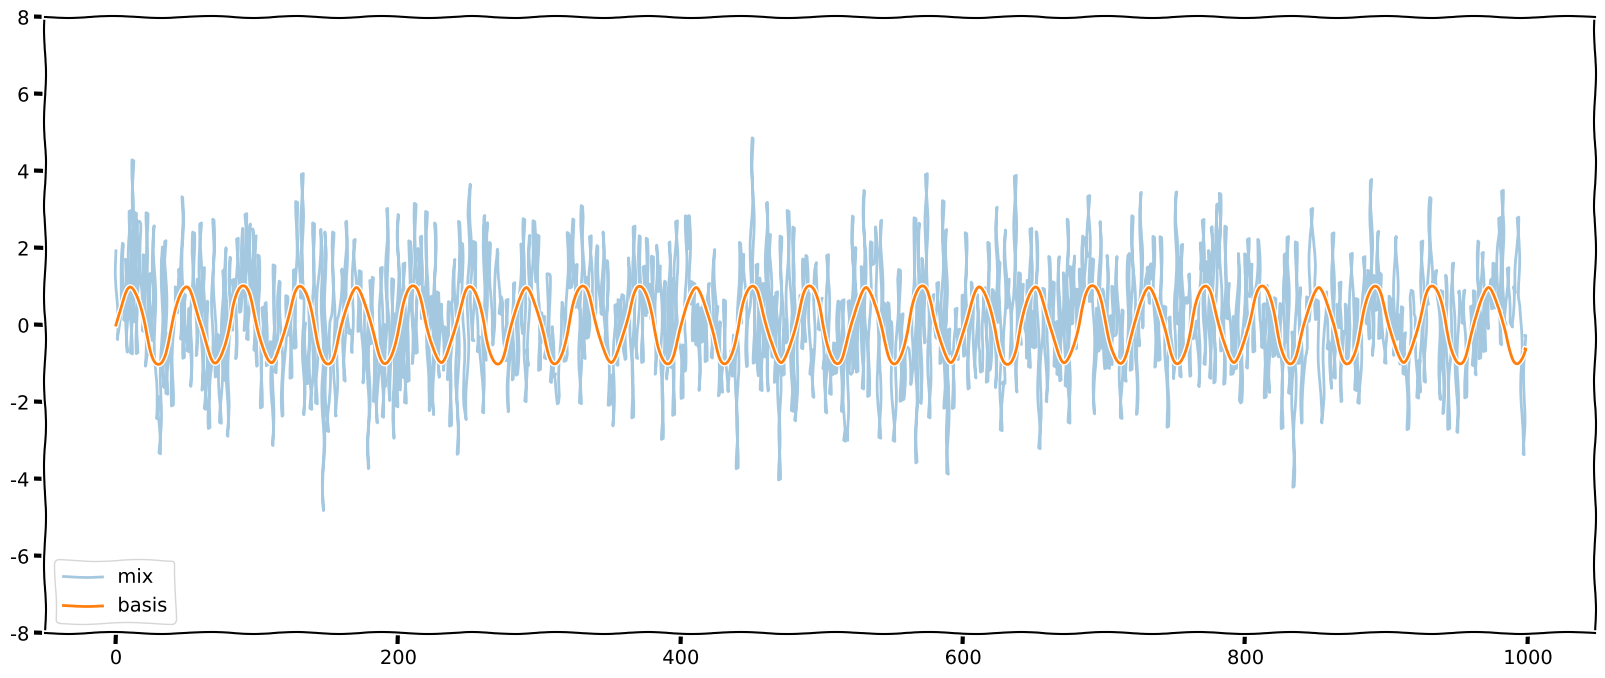

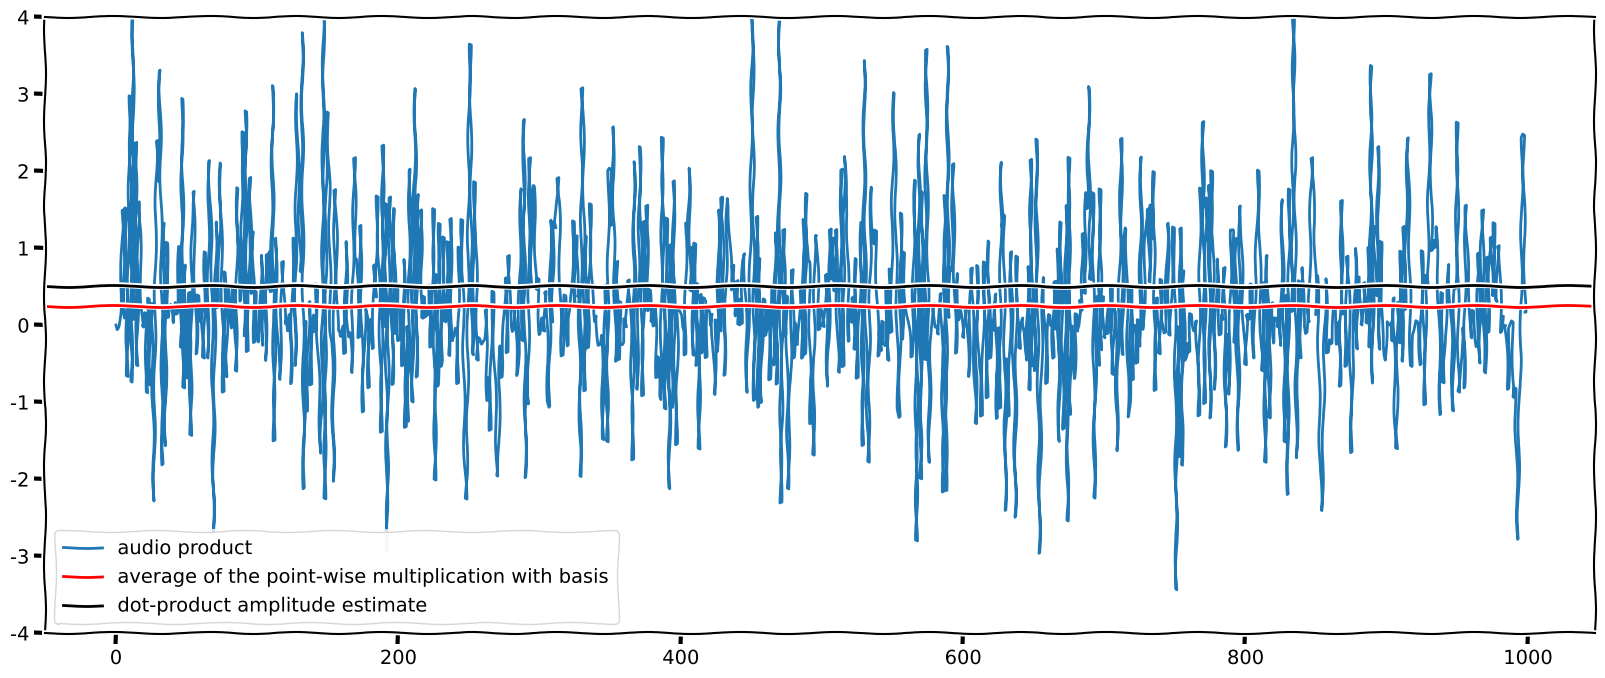

In [13]:
dur = audio1.shape[0] / srate
(t,basis) = generate_sinusoid(freq=freq, dur=dur, amp = 1)
basis = basis[0:999]
audio_product = np.multiply(mix[0:999],basis[0:999])
plt.figure()
plt.ylim((-8, 8))
plt.plot(mix[0:999], label = 'mix', alpha=0.4)
plt.plot(basis, label='basis')

plt.legend(loc='lower left')
plt.figure()
plt.ylim((-4, 4))
plt.plot(audio_product, label='audio product')

plt.axhline(y=np.mean(audio_product), color='r', linestyle='-', label='average of the point-wise multiplication with basis')
plt.axhline(y=2 * np.mean(audio_product), color='black', linestyle='-', label='dot-product amplitude estimate')
plt.legend(loc='lower left')

Now let's consider some other interference scenarios in which instead of noise we have a music recording acting as interference. **Notice that we are still able as human listeners to clearly hear the sinusoid while we hear the trumpet sound.** We can still estimate nicely the amplitude of the sinusoid despite the musical interference.


In [14]:
filename = librosa.ex('trumpet')
trumpet, sr = librosa.load(filename)
trumpet = 16.0 * trumpet[0:audio2.shape[0]]
print(trumpet.shape)
print(audio1.shape)
mix = audio1 + trumpet
ipd.Audio(mix, rate=srate)

(66150,)
(66150,)


Dot amplitude = 2.75 
Dot amplitude = 2.75 


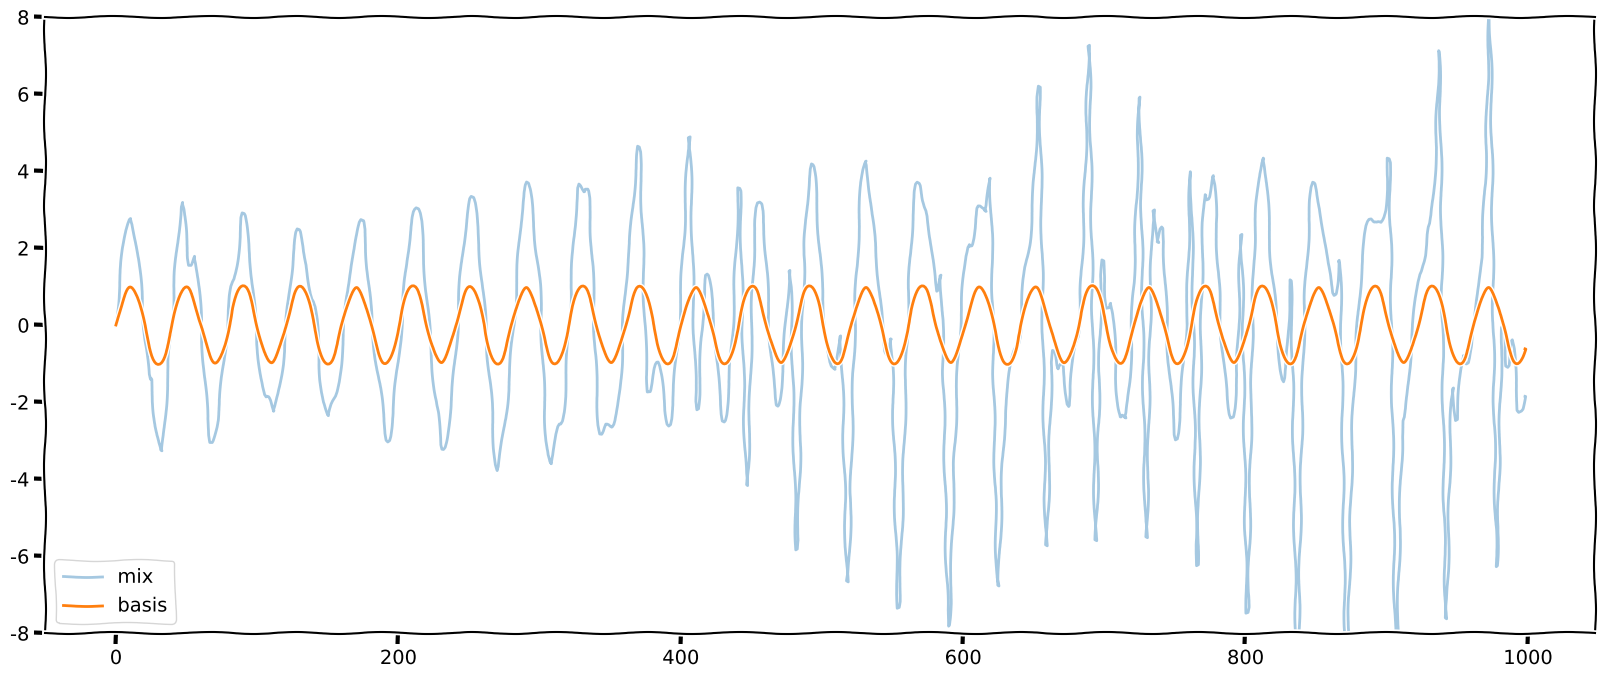

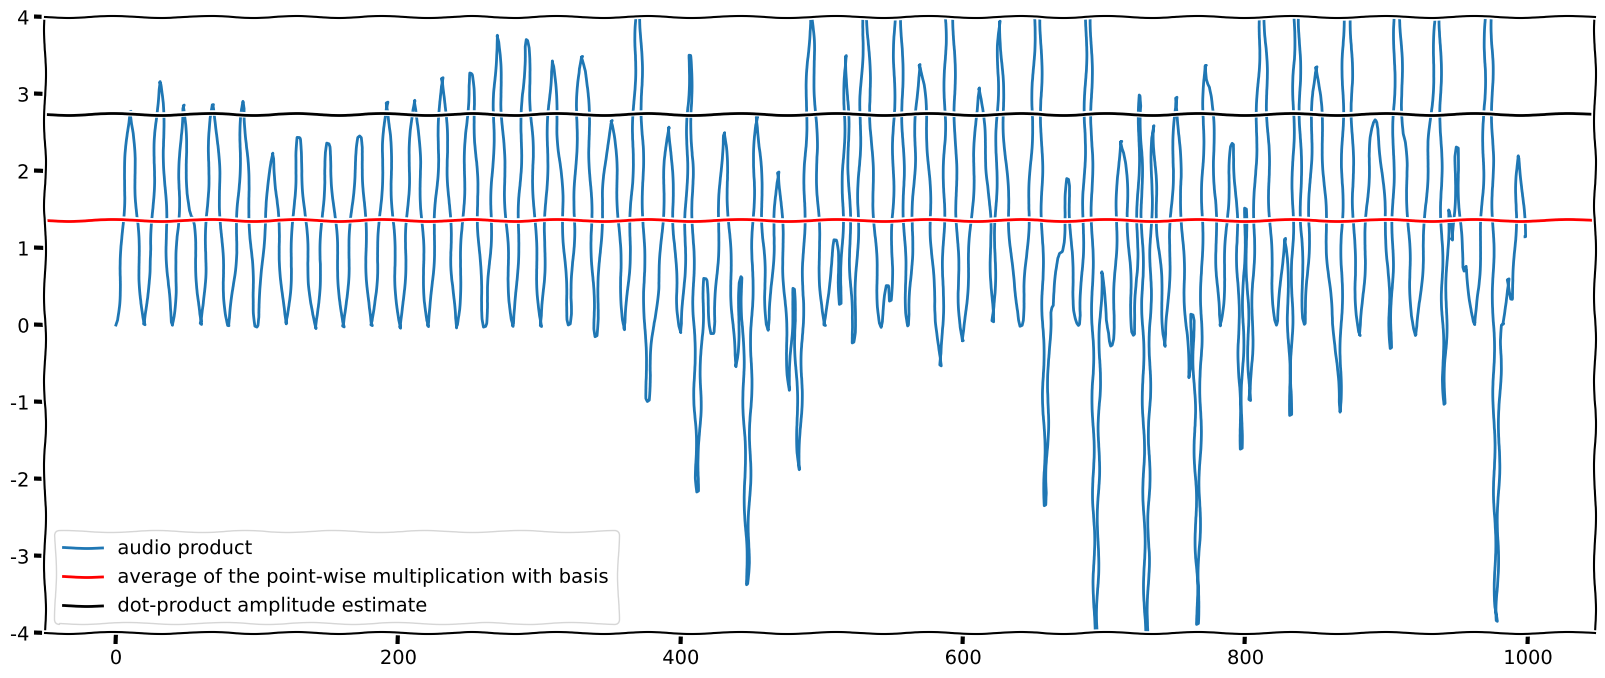

In [15]:
print('Dot amplitude = %2.2f ' % dot_amplitude_freq(audio1, freq))
print('Dot amplitude = %2.2f ' % dot_amplitude_freq(mix, freq))
dur = audio1.shape[0] / srate
(t,basis) = generate_sinusoid(freq=freq, dur=dur, amp = 1)

audio_product = np.multiply(mix[0:999],basis[0:999])
plt.figure()
plt.ylim((-8, 8))
plt.plot(mix[0:999], label = 'mix', alpha=0.4)
plt.plot(basis[0:999], label='basis')
plt.legend(loc='lower left')
plt.figure()
plt.ylim((-4, 4))

plt.plot(audio_product, label='audio product')

plt.axhline(y=np.mean(audio_product), color='r', linestyle='-', label='average of the point-wise multiplication with basis')
plt.axhline(y=2 * np.mean(audio_product), color='black', linestyle='-', label='dot-product amplitude estimate')
plt.legend(loc='lower left')

To summarize, we can estimate the amplitude of any sinusoid using peak estimation but this approach is very sensitive to noise and interference. RMS amplitude estimation is a more robust to noise but can still be inaccurate if the noise has higher amplitude than the sinusoid of interest. If we know the frequency we are looking for then by using the dot product of our mixture signal with a sinusoid with an amplitude of 1 (probe or basis) we can get very accurate amplitude estimation in the presence of noise or music. We do need to know what frequency we are looking for and the probe and the burried sinusoids must also be phase aligned. In the next part of the exposition we will see how we can deal with phase and time to improve our ability to analyze music and audio.

**Exercise for the reader** - experiment with the dot-product estimation with the input being a simple additive combination of sinusoidal signals. Generate
a sound consisting of three sinusoids with harmonically-related frequencies
and random amplitudes. Use three "probe" basis sinusoids with the same frequencies and unit amplitude as the mixture sound to estimate the random amplitudes from the mixture sound.The creation of a sound from adding harmonically related sinusoids is called additive synthesis.

